# Phase 2 -- Attention U-Net on Harbin, FILTERED ground truth

Trains on `Haerbing_ground_truth_filtered.tar` (NDVI persistence masks, with a morphological-opening filter removing farmland shelterbelt strands). See `code_phase2_harbin_unfiltered.ipynb` for the unfiltered counterpart, and `code_phase2_harbin_comparison.ipynb` to run after both are trained. See `poster_notes.md` for the full reasoning behind every decision made here.

In [ ]:
import os
# Force legacy Keras 2 behaviour. Current TF ships Keras 3 by default, which
# breaks this codebase's private optimizer-internals usage and the
# unmaintained `segmentation_models` package -- tf_keras is TF's official
# compatibility shim for exactly this situation, same fix already applied
# in predictor.py.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys
import numpy as np
import pandas as pd
import PIL
import requests
import tensorflow as tf
import tf_keras as keras
from tf_keras.models import *
from tf_keras.layers import *
from tf_keras.optimizers import *
from tf_keras.losses import *
from tf_keras import backend as K
from tf_keras.callbacks import ModelCheckpoint
from tf_keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import *


In [ ]:
# Colab setup: mount Drive, clone the repo, extract the ground-truth
# archive onto local disk (same reasoning as code_replicate.ipynb -- a
# single archive upload is far more reliable than uploading ~3,300
# individual .npy files through the browser).
import os

# This notebook is dedicated to the "filtered" ground-truth dataset only
# (see code_phase2_harbin_unfiltered.ipynb
# for the other one) -- kept as separate notebooks rather than a toggle
# variable so the two runs can't be mixed up. See poster_notes.md section 8
# for the filtered-vs-unfiltered ablation reasoning.
GROUND_TRUTH_VERSION = "filtered"

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = "/content/COMP0173_poster_pre"
    if not os.path.exists(REPO_DIR):
        !git clone -q https://github.com/jy-gfm/COMP0173_poster_pre.git {REPO_DIR}
    os.chdir(REPO_DIR)

    # Path to the tar archive you uploaded to Drive (adjust if yours lives elsewhere)
    TAR_NAME = f"Haerbing_ground_truth_{GROUND_TRUTH_VERSION}"
    DRIVE_TAR_PATH = f"/content/drive/MyDrive/COMP0173/{TAR_NAME}.tar"
    LOCAL_DATA_DIR = f"/content/{TAR_NAME}"

    if not os.path.exists(LOCAL_DATA_DIR):
        extract_root = f"/content/{TAR_NAME}_extract"
        os.makedirs(extract_root, exist_ok=True)
        !tar -xf {DRIVE_TAR_PATH} -C {extract_root}
        LOCAL_DATA_DIR = f"{extract_root}/{TAR_NAME}"

    DATA_DIR = LOCAL_DATA_DIR
else:
    DATA_DIR = f"./Haerbing_ground_truth_{GROUND_TRUTH_VERSION}"

print(f"GROUND_TRUTH_VERSION = {GROUND_TRUTH_VERSION}")
print(f"DATA_DIR = {DATA_DIR}")


## Data ingestion

Much simpler than the reproduction's ingestion step -- `generate-haerbing-ground-truth.py` already produced normalised `(512,512,4)` float32 image arrays and `(512,512,1)` uint8 mask arrays, so this is just loading `.npy` files, no PIL/casing handling needed.

In [ ]:
import numpy as np
import glob

def load_split(split):
    image_paths = sorted(glob.glob(f"{DATA_DIR}/{split}/images/*.npy"))
    images, masks = [], []
    for p in image_paths:
        images.append(np.load(p))
        masks.append(np.load(p.replace("/images/", "/masks/")))
    return images, masks

training_images, training_masks = load_split("training")
validation_images_raw, validation_masks_raw = load_split("validation")
test_images_raw, test_masks_raw = load_split("test")

# Match the shapes trainGenerator/score_eval expect (validation/test kept
# as a batch-of-1 list, same convention as code_replicate.ipynb)
validation_images = [im.reshape(1, 512, 512, 4) for im in validation_images_raw]
validation_masks = [m.reshape(1, 512, 512, 1) for m in validation_masks_raw]
test_images = [im.reshape(1, 512, 512, 4) for im in test_images_raw]
test_masks = [m.reshape(1, 512, 512, 1) for m in test_masks_raw]

print(f"training: {len(training_images)}, validation: {len(validation_images)}, test: {len(test_images)}")


training: 917, validation: 211, test: 184


## Sanity-check the ground-truth masks

Before training on anything, visually spot-check whether the NDVI-persistence
masks actually look like forest boundaries, or whether they're clearly
picking up cropland/other vegetation instead -- the same manual QC step the
original paper's authors did for their own k-means masks (re-classifying
until masks had a "satisfactory rating"). This doesn't need a trained model
-- it's just eyeballing the labels themselves.

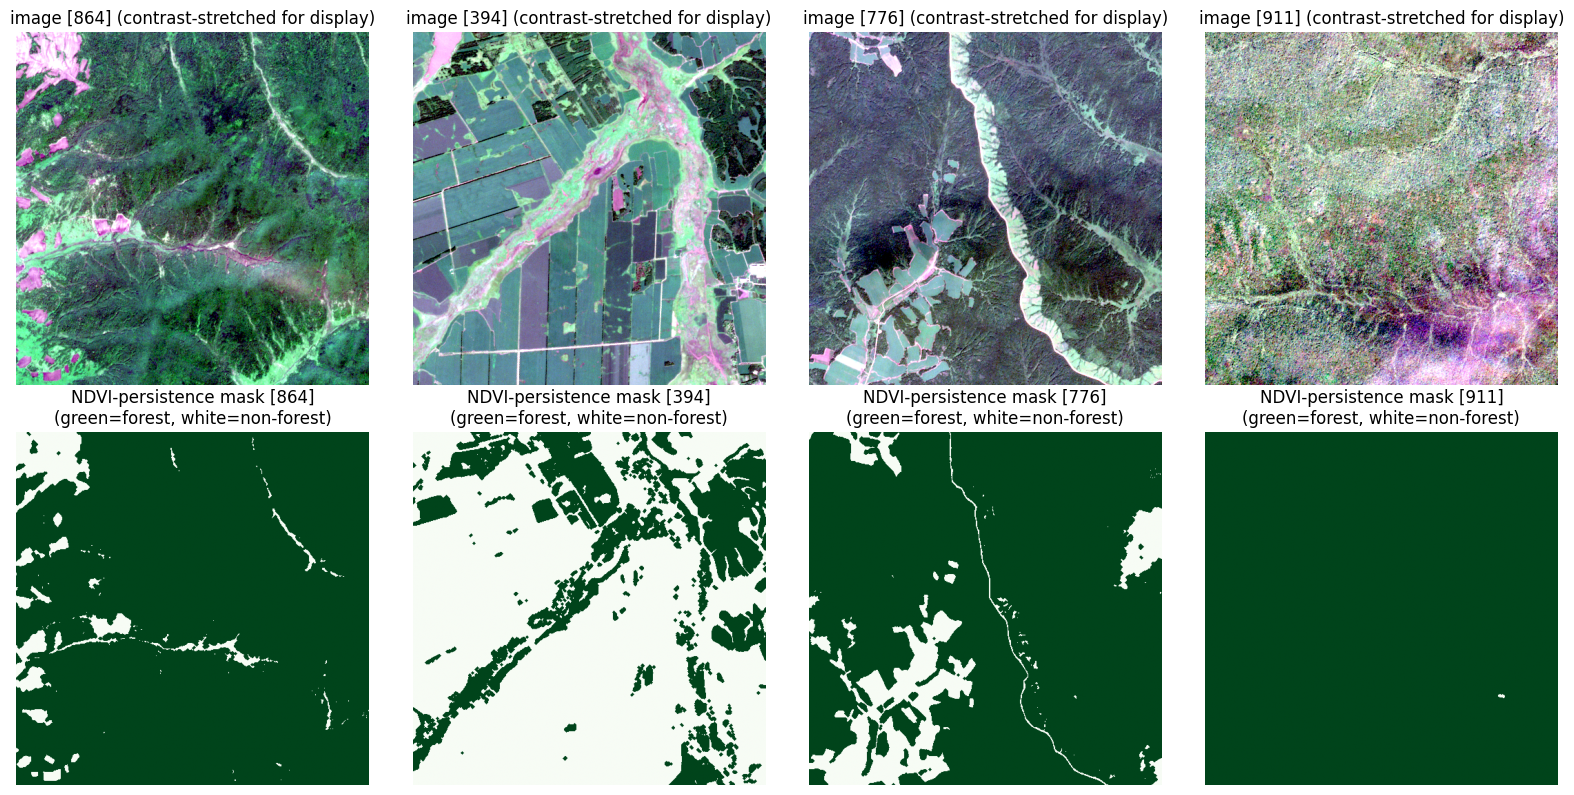

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def stretch_for_display(rgb, low_pct=2, high_pct=98, gamma=0.6):
    # Raw Sentinel-2 reflectance is typically 0.03-0.15 for land surfaces --
    # displaying it on a raw 0-1 scale looks almost black. This is a
    # display-only fix (percentile contrast stretch + gamma brightening);
    # it does not touch the actual numeric data used for training/eval.
    stretched = np.zeros_like(rgb)
    for c in range(rgb.shape[-1]):
        band = rgb[:, :, c]
        lo, hi = np.percentile(band, [low_pct, high_pct])
        stretched[:, :, c] = np.clip((band - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.clip(stretched, 0, 1) ** gamma

def show_image_mask_pairs(images, masks, n=4, seed=0):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(images)), min(n, len(images)))
    fig, axes = plt.subplots(2, len(idxs), figsize=(4 * len(idxs), 8))
    for col, i in enumerate(idxs):
        rgb = stretch_for_display(images[i][:, :, :3])  # drop NIR for display
        axes[0, col].imshow(rgb)
        axes[0, col].set_title(f"image [{i}] (contrast-stretched for display)")
        axes[0, col].axis("off")
        axes[1, col].imshow(masks[i].squeeze(), cmap="Greens", vmin=0, vmax=1)
        axes[1, col].set_title(f"NDVI-persistence mask [{i}]\n(green=forest, white=non-forest)")
        axes[1, col].axis("off")
    plt.tight_layout()
    plt.show()

show_image_mask_pairs(training_images, training_masks, n=4)


## Data augmentation generator

Same generator/augmentation settings as the reproduction.

In [ ]:
from tf_keras.preprocessing.image import ImageDataGenerator

def adjustData(img, mask, num_class):
    mask[mask > 0.5] = 1  # FOREST
    mask[mask <= 0.5] = 0  # NON-FOREST
    return (img, mask)

def trainGenerator(batch_size, image_array, mask_array, aug_dict,
                    image_save_prefix="image", mask_save_prefix="mask",
                    num_class=2, save_to_dir=None, target_size=(512, 512), seed=1):
    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array, batch_size=batch_size,
                                          save_to_dir=save_to_dir,
                                          save_prefix=image_save_prefix, seed=seed)
    mask_generator = mask_datagen.flow(mask_array, batch_size=batch_size,
                                        save_to_dir=save_to_dir,
                                        save_prefix=mask_save_prefix, seed=seed)

    train_generator = zip(image_generator, mask_generator)
    for (img, mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)

t_images = np.stack(training_images)
t_masks = np.stack(training_masks)

# Free the raw list copies now that we have the stacked arrays -- avoids
# holding both representations of the training data in memory at once,
# which is what caused the earlier out-of-RAM error on CPU. training_images/
# training_masks aren't referenced again after this point.
del training_images, training_masks
import gc
gc.collect()

import tensorflow as tf
validation_df = tf.data.Dataset.from_tensor_slices((validation_images, validation_masks))

data_gen_args = dict(rotation_range=180, width_shift_range=0.25, height_shift_range=0.25,
                      shear_range=0.25, zoom_range=0.25, horizontal_flip=True,
                      vertical_flip=True, fill_mode='reflect')


## Model architecture -- Attention U-Net

Identical to `code_replicate.ipynb` (same architecture, per the coursework requirement) -- `input_size` is set via the config below to `(512,512,4)` instead of `(512,512,3)`.

In [ ]:
'''
  Convolutional block with a single conv layer and activation
'''
def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
  else:
    conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
  conv = Activation(act)(conv)
  return conv

'''
  Convolutional block with two conv layers and two activation layers
'''
def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding='same', kernel_initializer=kernel_init)(conv)
    conv = Activation(act)(conv)
  return conv

'''
  U-Net model (baseline, no attention gates)
'''
def UNet(trained_weights=None, input_size=(512, 512, 3), drop_rate=0.25, lr=0.0001):
    inputs = Input(input_size, batch_size=1)

    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    up6 = Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5)
    merge6 = concatenate([conv4, up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)

    up7 = Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6)
    merge7 = concatenate([conv3, up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)

    up8 = Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7)
    merge8 = concatenate([conv2, up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)

    up9 = Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8)
    merge9 = concatenate([conv1, up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    out = convBlock(conv9, 1, 1, act='sigmoid')
    model = Model(inputs, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss=binary_crossentropy, metrics=['accuracy', 'mse'])

    if trained_weights is not None:
        model.load_weights(trained_weights)
    return model

'''
  Attention gate/block
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    theta_x = Conv2D(inter_shape, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2, 2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    phi_g = Conv2D(inter_shape, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(gating)

    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    psi = Conv2D(1, kernel_size=1, strides=1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    upsample_psi = tf.broadcast_to(upsample_psi, shape=shape_x)
    y = multiply([upsample_psi, x])
    return y

'''
  Attention U-Net model
'''
def UNetAM(trained_weights=None, input_size=(512, 512, 3), drop_rate=0.25, lr=0.0001, filter_base=16):
    inputs = Input(input_size, batch_size=1)

    conv = convBlock2(inputs, filter_base, 3)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)

    up4 = Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3)
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate)
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4)
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate)
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5)
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate)
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6)
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate)
    # Bug fix (architectural change, not just config): the previous version computed
    # the attention-gated merge7 here, then immediately discarded it by overwriting
    # conv7 with the raw, ungated skip connection on the next line -- so the finest-
    # resolution attention gate (the one operating at the highest spatial detail,
    # exactly where thin linear shelterbelt strands are distinguishable from blocky
    # forest cover) never actually influenced the trained model. Using the gated
    # merge7 result is the fix.
    conv7 = concatenate([up7, merge7])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    out = convBlock(conv7, 1, 1, act='sigmoid')
    model = Model(inputs, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss=binary_crossentropy, metrics=['accuracy', 'mse'])

    if trained_weights is not None:
        model.load_weights(trained_weights)
    return model


## Training config -- CONFIRMED (see poster_notes.md section 5)

| parameter | original (RGB Amazon) | Harbin (this notebook) | why |
|---|---|---|---|
| input bands | 3 | **4 (R,G,B,NIR)** | matches original paper's own 4-band variant, which scored higher than RGB |
| `filter_base` | 16 | **24** | more heterogeneous non-forest classes (cropland/grassland/wetland/urban) than the Amazon's cleared land |
| learning rate | 0.0005 | 0.0005 (unchanged) | already shown to work well for this architecture |
| steps/epoch | 100 (25 real images, heavy augmentation) | **len(t_images)** (~917 real images) | full pass over real data per epoch, much less reliant on augmentation to manufacture variety |
| epochs | 50 | **20** | far more real data per epoch than the original, so fewer epochs needed |
| batch size | 1 (hardcoded in `Input(...)`) | 1 (unchanged) | keeps the architecture identical; not modified for this run |
| train/val/test split | fixed 30/15/15 | **~70/15/15, split by (tile_id,row,col) position** | avoids leaking near-identical same-location tiles from different dates across splits |


In [ ]:
# Hyperparameters -- CONFIRMED phase-2 config
INPUT_SIZE = (512, 512, 4)
LEARNING_RATE = 0.0005
FILTER_BASE = 24
EPOCHS = 20
STEPS_PER_EPOCH = len(t_images)
# -archfix suffix keeps this run's weights/history separate from the original
# filtered-dataset model, so both can be evaluated and compared afterwards.
MODEL_OUT_PATH = f"unet-attention-4d-harbin-{GROUND_TRUTH_VERSION}-archfix.hdf5"

DRIVE_SAVE_DIR = "/content/drive/MyDrive/COMP0173/" if IN_COLAB else "./"


## Train Attention U-Net on Harbin data

In [ ]:
from tf_keras.callbacks import ModelCheckpoint

model_attention_unet_harbin = UNetAM(input_size=INPUT_SIZE, lr=LEARNING_RATE, filter_base=FILTER_BASE)
save_model_harbin = ModelCheckpoint(MODEL_OUT_PATH, monitor='val_accuracy', verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

history = model_attention_unet_harbin.fit(train, steps_per_epoch=STEPS_PER_EPOCH, epochs=EPOCHS,
                                           validation_data=validation_df, callbacks=[save_model_harbin])

np.save(MODEL_OUT_PATH.replace('.hdf5', '-history.npy'), history.history)


Epoch 1/20
917/917 [==============================] - ETA: 0s - loss: 0.6320 - accuracy: 0.6372 - mse: 0.2205
Epoch 1: val_accuracy improved from -inf to 0.76968, saving model to unet-attention-4d-harbin-filtered.hdf5


/usr/local/lib/python3.13/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


917/917 [==============================] - 177s 162ms/step - loss: 0.6320 - accuracy: 0.6372 - mse: 0.2205 - val_loss: 0.4718 - val_accuracy: 0.7697 - val_mse: 0.1546
Epoch 2/20
917/917 [==============================] - ETA: 0s - loss: 0.3740 - accuracy: 0.8390 - mse: 0.1161
Epoch 2: val_accuracy improved from 0.76968 to 0.87641, saving model to unet-attention-4d-harbin-filtered.hdf5
917/917 [==============================] - 141s 154ms/step - loss: 0.3740 - accuracy: 0.8390 - mse: 0.1161 - val_loss: 0.3124 - val_accuracy: 0.8764 - val_mse: 0.0946
Epoch 3/20
917/917 [==============================] - ETA: 0s - loss: 0.3432 - accuracy: 0.8575 - mse: 0.1047
Epoch 3: val_accuracy improved from 0.87641 to 0.87899, saving model to unet-attention-4d-harbin-filtered.hdf5
917/917 [==============================] - 143s 156ms/step - loss: 0.3432 - accuracy: 0.8575 - mse: 0.1047 - val_loss: 0.3036 - val_accuracy: 0.8790 - val_mse: 0.0914
Epoch 4/20
917/917 [==============================] - ETA

In [ ]:
# Copy the trained model and training history to Drive
import shutil

if IN_COLAB:
    shutil.copy(MODEL_OUT_PATH, DRIVE_SAVE_DIR)
    shutil.copy(MODEL_OUT_PATH.replace('.hdf5', '-history.npy'), DRIVE_SAVE_DIR)
    print(f"Saved model and history to {DRIVE_SAVE_DIR}")


Saved model and history to /content/drive/MyDrive/COMP0173/


## Evaluate

In [ ]:
'''
  Metric functions for evaluation (from Experimentation.ipynb)
'''
def score_eval(model, image, mask):
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()
    return accuracy_score(mask.flatten(), reconstruction)
  else:
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i])
      reconstruction = np.round(reconstruction).flatten()
      scores.append(accuracy_score(mask[i].flatten(), reconstruction))
    return scores

def recall_eval(model, image, mask):
  recall = []
  for i in range(len(image)):
      reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
      reconstruction = np.round(reconstruction).flatten()
      recall.append(recall_score(mask[i].flatten(), reconstruction, average='weighted'))
  return recall

def precision_eval(model, image, mask):
  precision = []
  for i in range(len(image)):
      reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
      reconstruction = np.round(reconstruction).flatten()
      precision.append(precision_score(mask[i].flatten(), reconstruction, average='weighted'))
  return precision

def f1_score_eval_basic(precision, recall):
    prec = np.mean(precision)
    rec = np.mean(recall)
    if prec + rec == 0:
        return 0
    return 2 * (prec * rec) / (prec + rec)


In [ ]:
am_unet_score_harbin = score_eval(model_attention_unet_harbin, validation_images, validation_masks)
am_unet_precision_harbin = precision_eval(model_attention_unet_harbin, validation_images, validation_masks)
am_unet_recall_harbin = recall_eval(model_attention_unet_harbin, validation_images, validation_masks)
am_unet_f1_harbin = f1_score_eval_basic(am_unet_precision_harbin, am_unet_recall_harbin)

# Report spread (std) across validation images alongside the mean, same
# convention as the original paper's own metrics_3d.csv (accuracy_std,
# precision_std, recall_std) -- this is a per-dataset characterization of
# performance variability, separate from the cross-model paired
# significance test in the final "Ablation comparison" section below.
harbin_metrics = {
    "accuracy": np.mean(am_unet_score_harbin),
    "accuracy_std": np.std(am_unet_score_harbin),
    "precision": np.mean(am_unet_precision_harbin),
    "precision_std": np.std(am_unet_precision_harbin),
    "recall": np.mean(am_unet_recall_harbin),
    "recall_std": np.std(am_unet_recall_harbin),
    "f1_score": am_unet_f1_harbin,
}

print(f"Model: {MODEL_OUT_PATH} (GROUND_TRUTH_VERSION={GROUND_TRUTH_VERSION})")
for k, v in harbin_metrics.items():
    print(f"  {k}: {v:.4f}")
harbin_metrics


## Visualize predictions vs. ground truth (failure case analysis)

Same comparison style as the original paper's Fig. 4 (image / ground truth /
prediction side by side). This is also direct material for the coursework's
"analyze failure cases" requirement (Part A.5d) -- look for systematic
patterns in where the model disagrees with the NDVI-persistence labels
(e.g. does it consistently call cropland "forest," matching the known
limitation of the labelling method?).

In [ ]:
from skimage.measure import label, regionprops
from matplotlib.patches import Circle

def circle_error_regions(ax, pred, gt, n_circles=2, min_area=5, color="red"):
    # Circles the n_circles largest connected regions where pred and gt
    # disagree -- an objective (not manually chosen) way to point at
    # where the model is making its biggest mistakes on a given tile.
    error_mask = (pred != gt)
    labeled = label(error_mask)
    regions = sorted(regionprops(labeled), key=lambda r: r.area, reverse=True)
    regions = [r for r in regions if r.area >= min_area][:n_circles]
    for r in regions:
        cy, cx = r.centroid
        radius = max(r.equivalent_diameter / 2, 15)
        circle = Circle((cx, cy), radius, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(circle)
    return regions


def show_predictions(model, images, masks, n=4, seed=0):
    rng = random.Random(seed)
    idxs = rng.sample(range(len(images)), min(n, len(images)))
    fig, axes = plt.subplots(3, len(idxs), figsize=(4 * len(idxs), 12))
    for col, i in enumerate(idxs):
        pred = np.round(model.predict(images[i])).reshape(512, 512)
        rgb = stretch_for_display(images[i].reshape(512, 512, 4)[:, :, :3])
        gt = masks[i].reshape(512, 512)

        print(f"image [{i}]: {(pred != gt).sum()} disagreeing pixels")

        axes[0, col].imshow(rgb)
        axes[0, col].set_title(f"image [{i}] (contrast-stretched for display)")
        axes[0, col].axis("off")
        axes[1, col].imshow(gt, cmap="Greens", vmin=0, vmax=1)
        axes[1, col].set_title("ground truth (NDVI-persistence)")
        axes[1, col].axis("off")
        axes[2, col].imshow(pred, cmap="Greens", vmin=0, vmax=1)
        axes[2, col].set_title("model prediction")
        axes[2, col].axis("off")
        circle_error_regions(axes[2, col], pred, gt, n_circles=2, min_area=5)
    plt.tight_layout()
    plt.show()

show_predictions(model_attention_unet_harbin, validation_images, validation_masks, n=4)


## Compare: original paper vs. reproduction vs. Harbin

**Note on interpretation (see poster_notes.md section 8): this comparison
evaluates model performance across contexts, not policy efficacy. A lower
score on Harbin data would not "disprove" the reforestation policy -- it
would reflect the harder labelling problem (persistent-vegetation proxy
covering cropland/grassland too) and the different landscape, which is
exactly the kind of failure-case analysis the coursework asks for.

In [ ]:
import pandas as pd

original_metrics = pd.read_csv("metrics/metrics_3d.csv", index_col=0)
original_am_unet = original_metrics[original_metrics["classifier"] == "Attention U-Net"].iloc[0]

# Confirmed results from code_replicate.ipynb's validated reproduction run
# (hardcoded here since this notebook runs in its own fresh Colab session,
# not the same kernel as code_replicate.ipynb -- see poster_notes.md section 2)
reproduced_metrics = {
    "accuracy": 0.9539, "precision": 0.9597, "recall": 0.9539, "f1_score": 0.9568,
}

three_way = pd.DataFrame({
    "original (RGB Amazon)": [original_am_unet["accuracy"], original_am_unet["precision"],
                               original_am_unet["recall"], original_am_unet["f1_score"]],
    "reproduced (RGB Amazon)": [reproduced_metrics["accuracy"], reproduced_metrics["precision"],
                                 reproduced_metrics["recall"], reproduced_metrics["f1_score"]],
    "Harbin (4-band, this notebook)": [harbin_metrics["accuracy"], harbin_metrics["precision"],
                                        harbin_metrics["recall"], harbin_metrics["f1_score"]],
}, index=["accuracy", "precision", "recall", "f1_score"])

print(three_way)


           original (RGB Amazon)  reproduced (RGB Amazon)  \
accuracy                0.952631                   0.9539   
precision               0.957403                   0.9597   
recall                  0.952631                   0.9539   
f1_score                0.955011                   0.9568   

           Harbin (4-band, this notebook)  
accuracy                         0.909334  
precision                        0.938865  
recall                           0.909334  
f1_score                         0.923864  
